# Setup


In [52]:
from dotenv import load_dotenv
import os
load_dotenv()

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

In [53]:
from datetime import datetime
from trustcall import create_extractor
from typing import Optional, Literal
from pydantic import BaseModel, Field

from langchain_core.runnables import RunnableConfig
from langchain_core.messages import merge_message_runs, HumanMessage, SystemMessage

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, MessagesState, END, START
from langgraph.store.base import BaseStore
from langgraph.store.memory import InMemoryStore
from langgraph.types import interrupt, Command

In [54]:
from typing import Annotated, TypedDict

In [55]:
from operator import add
from collections import Counter

In [56]:
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=1.0)

In [57]:
from exercise_7_states import DayVote, DayChannel, InvestigatorResult, OrchestratorGraph, WolfChannel

In [58]:
import random
characters = list(range(1, 9))

roles = [
    "villager", "villager", "villager", "villager",
    "wolf", "wolf",
    "healer",
    "investigator"
]

def initialize_game(state: OrchestratorGraph):
    roles = [
        "villager", "villager", "villager", "villager",
        "wolf", "wolf",
        "healer",
        "investigator"
    ]
    characters = [f'player_{i}' for i in range(1, 9)]
    human_player = random.choice(characters)
    
    random.shuffle(roles)
    assigned_roles = dict(zip(characters, roles))
    healer_player = [player for player, role in assigned_roles.items() if role == "healer"][0]
    investigator_player = [player for player, role in assigned_roles.items() if role == "investigator"][0]
    
    return {
        "roles": assigned_roles,
        "surviving_wolves": [player for player, role in assigned_roles.items() if role == "wolf"],
        "surviving_villagers": [player for player, role in assigned_roles.items() if role != "wolf"],
        "current_day": 1,
        "human_player": human_player,
        "healer_player": healer_player,
        "investigator_player": investigator_player
    }



        

## Prompt Templates

In [59]:
from langchain_core.prompts import ChatPromptTemplate

In [60]:
GAME_PREAMBLE = """You are playing a game of Werewolf with 8 players.

Team composition:
- 4 Villagers (no special abilities)
- 2 Wolves (know each other, secretly eliminate one villager per night)
- 1 Healer (can protect one player from elimination each night, cannot protect themselves)
- 1 Investigator (can reveal one player's role each night)

Win conditions:
- Villagers win when all wolves are eliminated.
- Wolves win when they equal or outnumber villagers.

Game flow:
- Day: all players discuss (3 rounds), then vote to eliminate one player. Ties result in no elimination.
- Night: wolves choose a target, healer may protect someone, investigator may investigate someone.
- Eliminated players' roles are revealed."""

In [61]:
VILLAGER_DAY_DISCUSS = ChatPromptTemplate.from_messages([
    ("system", GAME_PREAMBLE + """
        You are {player_id}, a {player_role}. 
        As a villager, you have no special abilities. Use reasoning and social deduction to figure out 
        who the wolves are and convince others to vote them out.
     
     You must respond with a valid JSON:
     {{"message" : "your discussion message"}}
    """
     ),
    ("human", """
     Day {current_day}, Discussion Round {current_round}.
     
     Suriving players: {surviving_players}
     
     == Chat history so far==
     {day_channel}
     =========================
     
     Based on the discussion so far, share your thoughts and suspicions with other players.
     """)
])

INVESTIGATOR_DAY_DISCUSS = ChatPromptTemplate.from_messages([
    ("system", GAME_PREAMBLE + """
        You are {player_id}, the {player_role}.
        As the investigator, you can use your investigation result to guide your decision.
        You are also to use reasoning and social deduction to figure out who are the wolves, as well
        as how to convince others to believe you, and vote the wolves out.
        
        You must respond with a valid JSON:
        {{"message": "Your discussion message"}}
        
        """),
    ("human", """
        Day {current_day}, Discussion round {current_round}.
        
        surviving players: {surviving_players}
        Investigation results: {investigator_results}
        
        == Chat history so far==
        {day_channel}
        =========================
     
        Based on the discussion so far and your investigation results, share your thoughts with others.
        """)
])

WOLF_DAY_DISCUSS = ChatPromptTemplate.from_messages(
    [
        ("system", GAME_PREAMBLE + """
        You are {player_id}, the {player_role}. 
        As the wolf, you are supposed to conceal your real identify and convince everyone else
        that you are an villager. If any of your fellow wolf allies are suspected of being a wolf, try your
        best to convince the villagers otherwise, without risking revealing your own identity.
        
        You must respond with a valid JSON:
        {{"message": "Your discussion message"}}
        """),
        ("human", """
         Day {current_day}, Discussion round {current_round}.
         Surviving villagers: {surviving_villagers}.
        Surviving allies: {surviving_wolves}.
        == Chat history so far==
        {day_channel}
        =========================
        Based on the discussion, try to speak like a villager. Do NOT reveal your allies identities.
        
         """)
    ]
)

In [62]:

DAY_VOTE_SYSTEM = GAME_PREAMBLE + """
You are {player_id}, a {player_role}.
You are now at the end of the current day of discussion. You are now to vote to eliminate a player you suspect is a wolf.
You must vote from one of the surviving players.
You cannot vote for yourself.

You must respond with a valid JSON:
{{"vote_target": "Player_X"}}
"""

DAY_VOTE_HUMAN_BASE = """Day {current_day}. Time to vote!

Here are the surviving players: {surviving_players}
{extra_context}

=== Discussion history so far ===
{day_channel}
=================================

Cast your vote. Choose the player you find most suspicious."""

VILLAGER_DAY_VOTE = ChatPromptTemplate.from_messages([
    ("system", DAY_VOTE_SYSTEM),
    
    ("human", """Day {current_day}. Time to vote!
     
     Here are the surviving players: {surviving_players}
     
     === discussion history so far ===
     {day_channel}
     =================================
     
     Cast your vote. Choose the player you find most suspicious. 
     """)
])

INVESTIGATOR_DAY_VOTE = ChatPromptTemplate.from_messages([
    ("system", DAY_VOTE_SYSTEM),
    
    ("human", """Day {current_day}. Time to vote!
     
     Here are the surviving players: {surviving_players}
     Here are your investigation results: {investigator_results}
     
     === discussion history so far ===
     {day_channel}
     =================================
     
     Cast your vote. Choose the player you find most suspicious. 
     """)
])

WOLF_DAY_VOTE = ChatPromptTemplate.from_messages([
    ("system", GAME_PREAMBLE + """
You are {player_id}, a {player_role}.
You are now voting to eliminate a player. 
You must NOT vote for your wolf allies. Vote for a villager instead.
Try to vote in a way that does not raise suspicion about your identity.

You must respond with a valid JSON:
{{"vote_target": "Player_X"}}
"""),
    ("human", """Day {current_day}. Time to vote!

Surviving villagers: {surviving_villagers}
Your wolf allies: {surviving_wolves}

=== Discussion history so far ===
{day_channel}
=================================

Cast your vote. Choose a villager to eliminate.""")
])

In [63]:
WOLF_NIGHT_DISCUSS = ChatPromptTemplate.from_messages([
    ("system", GAME_PREAMBLE + """
You are {player_id}, a {player_role}.
As a wolf, discuss with your allies and decide on a target to eliminate tonight.
There will be 2 rounds of discussion. In each round, share your reasoning and vote on a target.
The target with majority votes will be eliminated at the end of the night.
You may only vote for surviving villagers, not yourself or your allies.

You must respond with a valid JSON:
{{"message": "your discussion message", "vote_target": "Player_X"}}
"""),
    ("human", """Night of Day {current_day}, Discussion round {current_round}.

Surviving villagers: {surviving_villagers}
Your wolf allies: {surviving_wolves}

=== Day chat history ===
{day_channel}

=== Wolf night chat history ===
{wolf_channel}
=========================

Discuss with your allies and decide on a target.""")
])

In [64]:
HEALER_NIGHT = ChatPromptTemplate.from_messages([
    ("system", GAME_PREAMBLE + """
You are {player_id}, a {player_role}.
Each night, you may protect one player from being eliminated by the wolves.
You cannot protect yourself.
Choose wisely based on who you think the wolves might target.

You must respond with a valid JSON:
{{"healer_target": "Player_X"}}
"""),
    ("human", """Night of Day {current_day}.

Surviving players you can protect: {surviving_players}

=== Day chat history ===
{day_channel}
=========================

Choose a player to protect tonight.""")
])

INVESTIGATOR_NIGHT = ChatPromptTemplate.from_messages([
    ("system", GAME_PREAMBLE + """
You are {player_id}, a {player_role}.
Each night, you may investigate one player to learn their true role.
Use your past results and day discussions to choose your target wisely.
The result will be revealed to you at the start of the next day.

You must respond with a valid JSON:
{{"investigator_target": "Player_X"}}
"""),
    ("human", """Night of Day {current_day}.

Surviving players: {surviving_players}
Your past investigation results: {investigator_results}

=== Day chat history ===
{day_channel}
=========================

Choose a player to investigate tonight.""")
])

## Schemas


In [65]:
class WolfNightDiscussOutput(BaseModel):
    message: str
    vote_target: str
    
class DayDiscussOutput(BaseModel):
    message: str
    
class DayVoteOutput(BaseModel):
    vote_target: str
    
class HealerOutput(BaseModel):
    healer_target: str

class InvestigatorOutput(BaseModel):
    investigator_target: str


## Utility Helpers

In [66]:
def format_day_channel(messages: list[DayChannel]) -> str:
    if not messages:
        return "No messages yet."
    return "\n".join(
        f"[Day {m.day}, Round {m.round}] {m.player}: {m.message}"
        for m in messages
    )
    
def format_wolf_channel(messages: list[WolfChannel]) -> str:
    if not messages:
        return "No messages yet."
    return "\n".join(
        f"[Day {m.day}, Round {m.round}] {m.wolf}: {m.message}.  vote: {m.vote}"
        for m in messages
    )
    
def format_investigator_results(results: list[InvestigatorResult]) -> str:
    if not results:
        return "No investigations yet."
    return "\n".join(
        f"Day {r.day}: {r.player_investigated} was revealed as {r.role_revealed}"
        for r in results
    )

## Agent Node Factories

In [67]:
from langchain_core.prompts import ChatPromptTemplate


def _run_agent(payload: dict, prompt_template: ChatPromptTemplate, output_schema: type[BaseModel], output_key: str):
    chain = prompt_template | llm.with_structured_output(output_schema)
    
    prompt_input = {
        "player_id": payload.get("player_id", ""),
        "player_role": payload.get("player_role", ""),
        "current_day": payload.get("current_day", 1),
        "current_round": payload.get("current_round", 1),
        "surviving_players": ", ".join(payload.get("surviving_players", [])),
        "surviving_wolves": ", ".join(payload.get("surviving_wolves", [])),
        "surviving_villagers": ", ".join(payload.get("surviving_villagers", [])),
        "day_channel": format_day_channel(payload.get("day_channel", [])),
        "wolf_channel": format_wolf_channel(payload.get("wolf_channel", [])),
        "investigator_results": format_investigator_results(payload.get("investigator_results", [])),
    }
    
    result = chain.invoke(prompt_input)
    
    if output_key == "day_channel":
        return {"day_channel": [DayChannel(
            day=payload.get("current_day", 1),
            round=payload.get("current_round", 1),
            player=payload["player_id"],
            message=result.message,
        )]}
    elif output_key == "day_votes":
        return {"day_votes": [DayVote(
            voter=payload["player_id"],
            votee=result.vote_target,
        )]}
    elif output_key == "wolf_channel":
        return {"wolf_channel": [WolfChannel(
            day=payload.get("current_day", 1),
            round=payload.get("current_round", 1),
            wolf=payload["player_id"],
            message=result.message,
            vote=result.vote_target,
        )]}
    elif output_key == "healer_target":
        return {"healer_target": result.healer_target}
    elif output_key == "investigator_target":
        return {"investigator_target": result.investigator_target}
    





# Day Subgraph


In [68]:
class DayGraphState(TypedDict):
    current_day: int
    day_channel:Annotated[list[DayChannel], add]
    day_votes: Annotated[list[DayVote], add] 
    
    roles: dict[str, str]
    human_player: str
    
    investigator_player: str | None
    investigator_results: list[InvestigatorResult]
    
    surviving_villagers: list[str]
    surviving_wolves: list[str]
    
    current_round: int
    
class VillagerDayState(TypedDict):
    current_day: int
    current_round: int
    
    human_player: bool
    day_channel: list[DayChannel]
    surviving_players: list[str]
    player_id: str
    player_role: str
    
class InvestigatorDayState(TypedDict):
    current_day: int
    current_round: int
    
    human_player: bool
    day_channel: list[DayChannel]
    surviving_players: list[str]
    investigator_results: list[InvestigatorResult]
    player_id: str
    player_role: str

class WolfDayState(TypedDict):
    current_day: int
    current_round: int
    
    human_player: bool
    day_channel: list[DayChannel]
    surviving_wolves: list[str]
    surviving_villagers: list[str]
    player_id: str
    player_role: str

    

In [69]:
def prepare_round(state:DayGraphState):
    return {}

In [70]:
from langgraph.types import Send

def fan_out_day(state: DayGraphState, phase: Literal["discuss","vote"]):
    concurrent_nodes = []
    surviving_players = state["surviving_villagers"] + state["surviving_wolves"]
    for player in surviving_players:
        role = state["roles"][player]
        is_human = player == state["human_player"]
        
        if role in ("villager", "healer"):
            concurrent_nodes.append(
                Send(f"villager_{phase}", {
                    "human_player": is_human,
                    "day_channel": state["day_channel"],
                    "surviving_players": surviving_players,
                    "player_id": player,
                    "player_role": role,
                    "current_round": state["current_round"],
                    "current_day": state["current_day"],
                })
            )
        elif role == "wolf":
            concurrent_nodes.append(
                Send(f"wolf_{phase}", {
                    "human_player": is_human,
                    "day_channel": state["day_channel"],
                    "surviving_wolves": state["surviving_wolves"],
                    "surviving_villagers": state["surviving_villagers"],
                    "player_id": player,
                    "player_role": role,
                    "current_round": state["current_round"],
                    "current_day": state["current_day"],
                })
            )
        elif role == "investigator":
            concurrent_nodes.append(
                Send(f"investigator_{phase}", {
                    "human_player": is_human,
                    "day_channel": state["day_channel"],
                    "surviving_players": surviving_players,
                    "investigator_results": state["investigator_results"],
                    "player_id": player,
                    "player_role": role,
                    "current_round": state["current_round"],
                    "current_day": state["current_day"],
                })
            )
    
    return concurrent_nodes
    

def fan_out_discuss(state: DayGraphState):
    return fan_out_day(state, "discuss")

def fan_out_vote(state: DayGraphState):
    return fan_out_day(state, "vote")

In [71]:
from langgraph.types import interrupt

def villager_discuss(payload: VillagerDayState):
    return _run_agent(payload, VILLAGER_DAY_DISCUSS, DayDiscussOutput, "day_channel")

def wolf_discuss(payload: WolfDayState):
    return _run_agent(payload, WOLF_DAY_DISCUSS, DayDiscussOutput, "day_channel")

def investigator_discuss(payload: InvestigatorDayState):
    return _run_agent(payload, INVESTIGATOR_DAY_DISCUSS, DayDiscussOutput, "day_channel")

# Day vote nodes
def villager_vote(payload: VillagerDayState):
    return _run_agent(payload, VILLAGER_DAY_VOTE, DayVoteOutput, "day_votes")
def wolf_vote(payload: WolfDayState):
    return _run_agent(payload, WOLF_DAY_VOTE, DayVoteOutput, "day_votes")
def investigator_vote(payload: InvestigatorDayState):
    return _run_agent(payload, INVESTIGATOR_DAY_VOTE, DayVoteOutput, "day_votes")


In [72]:
def collect_discussion(state: DayGraphState):
    # Nothing to do — reducer already merged all DayChannel messages
    # This node just exists as a convergence point for routing
    return {"current_round": state["current_round"] + 1}

def check_round(state: DayGraphState) -> Literal["PREPARE_ROUND", "START_VOTING", "__end__"]:
    if state["current_day"] == 1:
        return END
    if state["current_round"] <= 3:
        return "PREPARE_ROUND"
    return "START_VOTING"

def start_voting(state: DayGraphState):
    return {}

def collect_votes(state: DayGraphState):
    return {}

In [73]:
day_graph = StateGraph(DayGraphState)

day_graph.add_node("PREPARE_ROUND", prepare_round)
day_graph.add_node("COLLECT_DISCUSSION", collect_discussion)
day_graph.add_node("START_VOTING", start_voting)
day_graph.add_node("COLLECT_VOTES", collect_votes)

day_graph.add_node("villager_discuss", villager_discuss)
day_graph.add_node("wolf_discuss", wolf_discuss)
day_graph.add_node("investigator_discuss", investigator_discuss)

day_graph.add_node("villager_vote", villager_vote)
day_graph.add_node("wolf_vote", wolf_vote)
day_graph.add_node("investigator_vote", investigator_vote)

day_graph.add_edge(START, "PREPARE_ROUND")

day_graph.add_conditional_edges("PREPARE_ROUND", fan_out_discuss, 
    ["villager_discuss", "wolf_discuss", "investigator_discuss"])
day_graph.add_edge("villager_discuss", "COLLECT_DISCUSSION")
day_graph.add_edge("wolf_discuss", "COLLECT_DISCUSSION")
day_graph.add_edge("investigator_discuss", "COLLECT_DISCUSSION")

day_graph.add_conditional_edges("COLLECT_DISCUSSION", check_round)
day_graph.add_conditional_edges("START_VOTING", fan_out_vote, ["villager_vote", "wolf_vote", "investigator_vote"])
day_graph.add_edge("villager_vote", "COLLECT_VOTES")
day_graph.add_edge("wolf_vote", "COLLECT_VOTES")
day_graph.add_edge("investigator_vote", "COLLECT_VOTES")
day_graph.add_edge("COLLECT_VOTES", END)



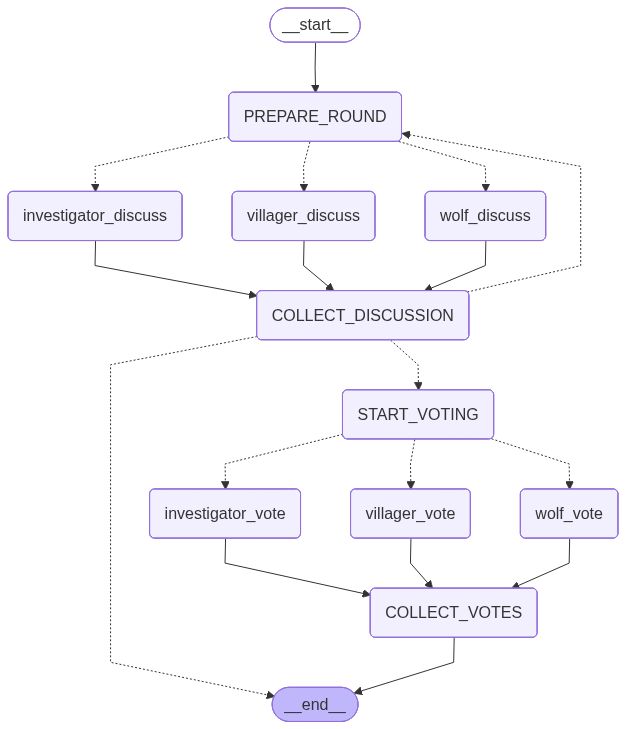

In [74]:
day_graph_compiled = day_graph.compile()
day_graph_compiled

In [75]:
day_graph_compiled = day_graph.compile()

def day_phase(state: OrchestratorGraph):
    # Filter parent state → DayGraph input
    result = day_graph_compiled.invoke({
        "current_day": state["current_day"],
        "day_channel": state["day_channel"],
        "roles": state["roles"],
        "human_player": state["human_player"],
        "investigator_results": state.get("investigator_results", []),
        "surviving_players": state["surviving_wolves"] + state["surviving_villagers"],
        "surviving_wolves": state["surviving_wolves"],
        "surviving_villagers": state["surviving_villagers"],
        "current_round": 1,
        "day_votes": [],
    })
    
    # Map subgraph output → parent state keys
    return {
        "day_channel": result["day_channel"][len(state["day_channel"]):],  # append new messages to existing channel
        "day_votes": result["day_votes"],
    }

# Wolf Night Subgraph


In [76]:
class WolfNightGraph(TypedDict):
    day_channel: list[DayChannel]
    wolf_channel: Annotated[list[WolfChannel], add]
    surviving_wolves: list[str]
    surviving_villagers: list[str]
    
    human_player: str
    
    current_day: int
    wolves_kill_target: str | None
    
    current_round: int
    

In [77]:
class WolfNightState(TypedDict):
    # information to facilitate discussion and voting among wolves
    day_channel: list[DayChannel]
    wolf_channel: list[WolfChannel] 
    
    surviving_villagers: list[str] # for knowing who the targets are
    surviving_wolves: list[str] # For knowing who the allies are
    
    player_id: str
    player_role: str
    human_player: bool
    
    current_day: int
    current_round: int
    


In [78]:
def prepare_wolf_night(state:WolfNightGraph):
    # initialize current round to 1 if not exist, otherwise keep it unchanged for subsequent rounds
    current_round = state.get("current_round", 1)
    if len(state["surviving_wolves"]) == 1:
        current_round = 2
    return {"current_round": current_round}


def wolf_fan_out(state: WolfNightGraph):    
    concurrent_nodes = []
        
    for wolf in state["surviving_wolves"]:
        is_human = wolf == state["human_player"]
        concurrent_nodes.append(
            Send("WOLF_NIGHT_DISCUSS", {
                "day_channel": state["day_channel"],
                "wolf_channel": state["wolf_channel"],
                "surviving_villagers": state["surviving_villagers"],
                "surviving_wolves": state["surviving_wolves"],
                "player_id": wolf,
                "player_role": "wolf",
                "human_player": is_human,
                "current_day": state["current_day"],
                "current_round": state["current_round"],
            })
        )
    return concurrent_nodes

def wolf_night_discuss(payload: WolfNightState):
    return _run_agent(payload, WOLF_NIGHT_DISCUSS, WolfNightDiscussOutput, "wolf_channel")
    
def collect_wolf_night_discussion(state: WolfNightGraph):
    # reducer will merge all wolf_channel messages into state["wolf_channel"]
    if state["current_round"] >= 2:
        final_votes = [
            msg.vote
            for msg in state["wolf_channel"]
            if msg.round == 2 and msg.day == state["current_day"]
        ]
        msg_count = Counter(final_votes)
        max_votes = max(msg_count.values(), default=0)
        candidates = [player for player, votes in msg_count.items() if votes == max_votes]
        if len(candidates) == 1:
            return {"wolves_kill_target": candidates[0]}

            # random target chosen among tied candidates
        return {"wolves_kill_target": random.choice(candidates)}
    else:
        return {"current_round": state["current_round"] + 1}
        

In [79]:
def check_night_end(state: WolfNightGraph) -> Literal["PREPARE_WOLF_NIGHT", "__end__"]:
    if state.get("wolves_kill_target") is not None:
        return END
    return "PREPARE_WOLF_NIGHT"
    

In [80]:
wolf_night_graph = StateGraph(WolfNightGraph)

wolf_night_graph.add_node("PREPARE_WOLF_NIGHT", prepare_wolf_night)
wolf_night_graph.add_node("WOLF_NIGHT_DISCUSS", wolf_night_discuss)
wolf_night_graph.add_node("COLLECT_WOLF_NIGHT_DISCUSSION", collect_wolf_night_discussion)

wolf_night_graph.add_edge(START, "PREPARE_WOLF_NIGHT")
wolf_night_graph.add_conditional_edges("PREPARE_WOLF_NIGHT", wolf_fan_out, ["WOLF_NIGHT_DISCUSS"])
wolf_night_graph.add_edge("WOLF_NIGHT_DISCUSS", "COLLECT_WOLF_NIGHT_DISCUSSION")
wolf_night_graph.add_conditional_edges("COLLECT_WOLF_NIGHT_DISCUSSION", check_night_end)


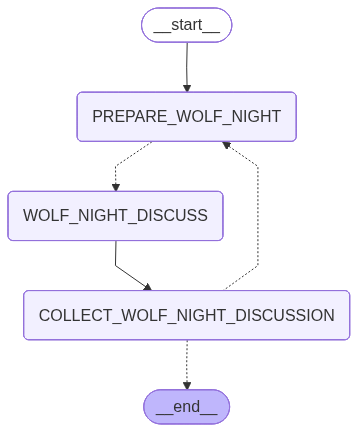

In [81]:
wolf_night_graph_compiled = wolf_night_graph.compile()
wolf_night_graph_compiled

In [82]:
def wolf_night_phase(state: OrchestratorGraph):
    result = wolf_night_graph_compiled.invoke({
        "day_channel": state["day_channel"],
        "wolf_channel": state["wolf_channel"],
        "surviving_villagers": state["surviving_villagers"],
        "surviving_wolves": state["surviving_wolves"],
        "human_player": state["human_player"],
        "current_day": state["current_day"],
    })
    
    return {
        "wolf_channel": result["wolf_channel"][len(state["wolf_channel"]):], # only keep new messages generated in this phase
        "wolves_kill_target": result.get("wolves_kill_target"),
    }

# Healer And Investigator Subgraphs


In [83]:
class InvestigatorNightGraph(TypedDict):
    day_channel: list[DayChannel]
    
    investigator_results: list[InvestigatorResult]
    
    surviving_players: list[str]
    player_id: str
    player_role: str
    
    human_player: bool
    
    investigator_target: str | None

In [84]:
class HealerNightGraph(TypedDict):
    day_channel: list[DayChannel]
    surviving_players: list[str]
    player_id: str
    player_role: str
    human_player: bool
    
    healer_target: str | None


In [85]:
def wolf_night_discuss(payload: WolfNightState):
    return _run_agent(payload, WOLF_NIGHT_DISCUSS, WolfNightDiscussOutput, "wolf_channel")

def healer_act(payload: HealerNightGraph):
    return _run_agent(payload, HEALER_NIGHT, HealerOutput, "healer_target")

def investigator_act(payload: InvestigatorNightGraph):
    return _run_agent(payload, INVESTIGATOR_NIGHT, InvestigatorOutput, "investigator_target")

In [86]:
healer_graph = StateGraph(HealerNightGraph)
healer_graph.add_node("healer_act", healer_act)
healer_graph.add_edge(START, "healer_act")
healer_graph.add_edge("healer_act", END)

investigator_graph = StateGraph(InvestigatorNightGraph)
investigator_graph.add_node("investigator_act", investigator_act)
investigator_graph.add_edge(START, "investigator_act")
investigator_graph.add_edge("investigator_act", END)

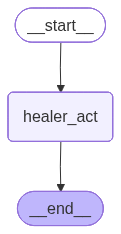

In [87]:
healer_graph_compiled = healer_graph.compile()
healer_graph_compiled


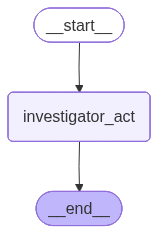

In [88]:
investigator_graph_compiled = investigator_graph.compile()
investigator_graph_compiled

In [89]:
def healer_night_phase(state: OrchestratorGraph):
    result = healer_graph_compiled.invoke({
        "day_channel": state["day_channel"],
        "surviving_players": [p for p in state["surviving_wolves"] + state["surviving_villagers"] if p != state["healer_player"]],
        "player_id": state["healer_player"],
        "player_role": "healer",
        "human_player": state["healer_player"] == state["human_player"],
    })
    
    return {
        "healer_target": result["healer_target"]
    }

def investigator_night_phase(state: OrchestratorGraph):
    result = investigator_graph_compiled.invoke({
        "day_channel": state["day_channel"],
        "investigator_results": state.get("investigator_results", []),
        "surviving_players": [p for p in state["surviving_wolves"] + state["surviving_villagers"] if p != state["investigator_player"]],
        "player_id": state["investigator_player"],
        "player_role": "investigator",
        "human_player": state["investigator_player"] == state["human_player"],
    })
    
    return {
        "investigator_target": result["investigator_target"]
    }

# Parent Orchestrator Graph


In [ ]:
def day_resolution(state: OrchestratorGraph):
    day_votes = state.get("day_votes", [])
    
    if not day_votes:
        # End of day with no votes. 
        return {"day_channel": [DayChannel(
            day=state.get("current_day", 1),
            round=0,
            player="game_master",
            message=f"Day {state.get('current_day', 1)}: No vote was held today."
        )]}
        
    vote_summary = "\n".join(f"  {v.voter} voted for {v.votee}" for v in day_votes) 
    vote_counts = Counter(vote.votee for vote in day_votes)
    
    max_votes = max(vote_counts.values(), default=0)
    candidates = [player for player, votes in vote_counts.items() if votes == max_votes]
    
    voted_player = None
    if len(candidates) == 1:
        voted_player = candidates[0]
        surviving_wolves = [p for p in state['surviving_wolves'] if p != voted_player]
        surviving_villagers = [p for p in state['surviving_villagers'] if p != voted_player]
        
        state_update = {
            "voted_player": voted_player,
            "surviving_wolves": surviving_wolves,
            "surviving_villagers": surviving_villagers,
            "day_channel": [DayChannel(
                day=state.get('current_day', 1),
                round=state.get('current_round', 1),
                player='game_master',
                message=f"""
                Here's the vote result for day {state.get('current_day', 1)}:
                {vote_summary}
                Player {voted_player} has been voted out and was a {state['roles'][voted_player]}.  
                """     
            )],
        }
        
        if voted_player == state['healer_player']:
            state_update["healer_player"] = None
        if voted_player == state['investigator_player']:
            state_update["investigator_player"] = None
        
        return state_update
    
    return {"day_channel": [DayChannel(
                day=state.get('current_day', 1),
                round=state.get('current_round', 0),
                player='game_master',
                message=f"""
                Here's the vote result for day {state.get('current_day', 1)}:
                {vote_summary}
                It's a tie between players {candidates}. No one is voted out this day."""
                )],
            }


In [ ]:
def night_resolution(state: OrchestratorGraph):
    wolves_target = state.get("wolves_kill_target", "")
    healer_target = state.get("healer_target", "")
    current_day = state.get("current_day", 1)
    investigator_target = state.get("investigator_target", "")
    
    investigated_role = state["roles"].get(investigator_target, "unknown")


    if wolves_target and wolves_target != healer_target:
        surviving_villagers = [
            player
            for player in state["surviving_villagers"]
            if player != wolves_target
        ]
        
        state_update = {
            "surviving_villagers": surviving_villagers,
            "investigate_outcome": [InvestigatorResult(
                day=current_day,
                player_investigated=investigator_target,
                role_revealed=investigated_role
            )],
            "day_channel": [
                DayChannel(
                    day=current_day,
                    round=state.get("current_round", 0),
                    player="game_master",
                    message=(
                        f"{wolves_target} was killed by the wolves last night. "
                        f"They were a {state['roles'][wolves_target]}."
                    ),
                )
            ],
        }
        
        if wolves_target == state['healer_player']:
            state_update["healer_player"] = None
        if wolves_target == state['investigator_player']:
            state_update["investigator_player"] = None

        if investigator_target:
            state_update["investigator_results"] = [InvestigatorResult(
                day=current_day,
                player_investigated=investigator_target,
                role_revealed=investigated_role
            )]

        return state_update

    elif wolves_target and wolves_target == healer_target:
        return {
            "investigator_results": [InvestigatorResult(
                day=current_day,
                player_investigated=investigator_target,
                role_revealed=investigated_role
            )],
            "day_channel": [
                DayChannel(
                    day=current_day,
                    round=state.get("current_round", 0),
                    player="game_master",
                    message=(
                        f"{wolves_target} was targeted by the wolves last night, "
                        "but was saved by the healer!"
                    ),
                )
            ],
        }

    return {}

In [92]:
def one_more_day(state: OrchestratorGraph):
    return {
        "current_day": state.get("current_day", 1) + 1,
        "day_votes": None,
        "wolves_kill_target": None,
        "healer_target": None,
        "investigator_target": None,
        "voted_player": None,
    }

In [93]:
def route_after_wolf_night(state: OrchestratorGraph) -> Literal["HEALER_NIGHT_PHASE", "INVESTIGATOR_NIGHT_PHASE", "NIGHT_RESOLUTION"]:
    if state["healer_player"]:
        return "HEALER_NIGHT_PHASE"
    if state["investigator_player"]:
        return "INVESTIGATOR_NIGHT_PHASE"
    return "NIGHT_RESOLUTION"

def route_after_healer_night(state: OrchestratorGraph) -> Literal["INVESTIGATOR_NIGHT_PHASE", "NIGHT_RESOLUTION"]:
    if state["investigator_player"]:
        return "INVESTIGATOR_NIGHT_PHASE"
    return "NIGHT_RESOLUTION"

In [94]:
def end_game(state: OrchestratorGraph):
    if not state['surviving_wolves']:
        winner = "villagers"
    else:
        winner = "wolves"
    
    return {
        "winner": winner,
        "day_channel": [DayChannel(
            day=state.get("current_day", 1),
            round=0,
            player="game_master",
            message=f"Game over! The {winner} have won!"
        )]
    }

In [95]:
def check_game_end_day(state: OrchestratorGraph) -> Literal["END_GAME", "WOLF_NIGHT_PHASE"]:
    if not state['surviving_wolves']:
        return "END_GAME"
    elif len(state['surviving_wolves']) >= len(state['surviving_villagers']):
        return "END_GAME"
    return "WOLF_NIGHT_PHASE"

def check_game_end_night(state: OrchestratorGraph) -> Literal["END_GAME", "ONE_MORE_DAY"]:
    if not state['surviving_wolves']:
        return "END_GAME"
    elif len(state['surviving_wolves']) >= len(state['surviving_villagers']):
        return "END_GAME"
    return "ONE_MORE_DAY"

In [96]:
parent_graph = StateGraph(OrchestratorGraph)

# parent graph nodes
parent_graph.add_node("INITIALIZE_GAME", initialize_game)
parent_graph.add_node("DAY_PHASE", day_phase)
parent_graph.add_node("DAY_RESOLUTION", day_resolution)
parent_graph.add_node("WOLF_NIGHT_PHASE", wolf_night_phase)
parent_graph.add_node("HEALER_NIGHT_PHASE", healer_night_phase)
parent_graph.add_node("INVESTIGATOR_NIGHT_PHASE", investigator_night_phase)
parent_graph.add_node("NIGHT_RESOLUTION", night_resolution)
parent_graph.add_node("ONE_MORE_DAY", one_more_day)
parent_graph.add_node("END_GAME", end_game)

# add edge
parent_graph.add_edge(START, "INITIALIZE_GAME")
parent_graph.add_edge("INITIALIZE_GAME", "DAY_PHASE")
parent_graph.add_edge("DAY_PHASE", "DAY_RESOLUTION")
parent_graph.add_conditional_edges("DAY_RESOLUTION", check_game_end_day)
parent_graph.add_conditional_edges("WOLF_NIGHT_PHASE", route_after_wolf_night)
parent_graph.add_conditional_edges("HEALER_NIGHT_PHASE", route_after_healer_night)
parent_graph.add_conditional_edges("NIGHT_RESOLUTION", check_game_end_night)
parent_graph.add_edge("INVESTIGATOR_NIGHT_PHASE", "NIGHT_RESOLUTION")
parent_graph.add_edge("ONE_MORE_DAY", "DAY_PHASE")
parent_graph.add_edge("END_GAME", END)

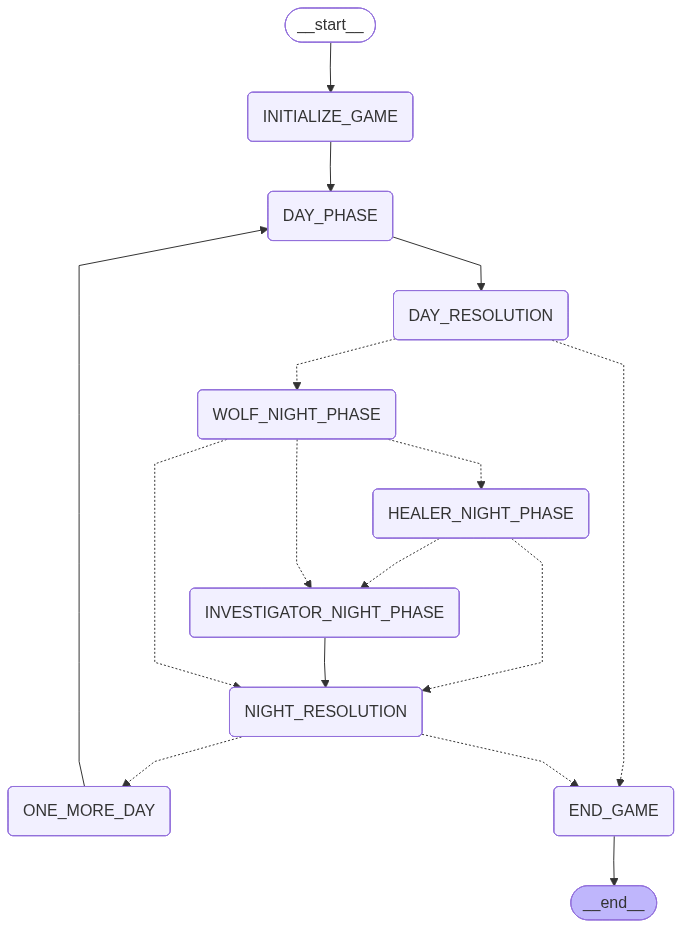

In [97]:
parent_graph_compiled = parent_graph.compile()
parent_graph_compiled

In [98]:
from langfuse.langchain import CallbackHandler
langfuse_handler = CallbackHandler()

In [99]:
# Compile parent graph (no checkpointer needed yet — no human interrupt)
parent_graph_compiled = parent_graph.compile()

# Run the game
result = parent_graph_compiled.invoke({},
    config={"callbacks": [langfuse_handler]}
)

# Check outcome
print(f"Winner: {result['winner']}")
print(f"Game lasted {result['current_day']} days")
print(f"Surviving wolves: {result['surviving_wolves']}")
print(f"Surviving villagers: {result['surviving_villagers']}")

# View the full day channel
for msg in result["day_channel"]:
    print(f"[Day {msg.day}, Round {msg.round}] {msg.player}: {msg.message}")

Winner: villagers
Game lasted 4 days
Surviving wolves: []
Surviving villagers: ['player_2', 'player_4', 'player_5']
[Day 1, Round 1] player_2: Good morning everyone. First day, no information, so let's start by hearing from everyone. Anyone want to kick us off with their initial thoughts or feelings about the group?
[Day 1, Round 1] player_3: Hello everyone! As a villager, my main goal is to identify the wolves. Since it's the first round and we have no information, I think we should all try to share our initial thoughts. Does anyone have any early suspicions or anything they want to bring up?
[Day 1, Round 1] player_4: Hello everyone. It's Day 1, so let's start by hearing from everyone. What are your initial thoughts or observations? We should try to get to know each other a bit.
[Day 1, Round 1] player_5: Alright everyone, Day 1! No information to go on yet, so let's hear from everyone. What are your initial thoughts or gut feelings? Any player want to kick us off?
[Day 1, Round 1] p